### IBM QAOA Parameter Setting Analysis ###
This notebook produces tables and generates plots to analyze real IBM Qunatum hardware data while running QAOA on ensembles of the MaxCut problem. Various training strategies are utilized to determine the optimal parameters (angles of QAOA) before running them on hardware. The idea is to create a resource-cost estimation for these different parameter setting strategies and suggest best practices.

In [1]:
%load_ext autoreload
%autoreload 2

# Path imports
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# IBM QAOA package specific
from src.Processing import QAOAHardware, QAOATraining
from src.Processing import set_data_path
from src.Processing import load_problem_instance
from src.approx_ratio_calc import get_minmax, extract_minmax_args, maxcut_approximation_ratio
from src.utils import (
    is_empty_nested_list,
    counts_to_samples_df,
    plot_ar_hist_by_training_method_with_points,
    plot_training_bricks,
    make_asof_per_file,
    sem,
    title_from_instance_names,
)

# General useful Python libraries
import pandas as pd 
import matplotlib.pyplot as plt 
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
import matplotlib.colors as mcolors
import numpy as np  
from pathlib import Path
from IPython.display import display
import math
import json

# Add stochastic-benchmark src to path and import related libraries
sys.path.append('../../src')
import stochastic_benchmark as SB
import bootstrap
import interpolate
import stats
from utils_ws import *
from plotting import Plotting
from plotting import ws_style

#### Data Analysis for IBM Quantum Hardware Data ####

In [2]:
# Select graph to explore
graph_type = "heavy_hex"

# Set data path
data_dir = "/mnt/c/Users/rames102/Desktop/QAOA-Parameter-Setting/data"
# Set instance path
inst_path = "/mnt/c/Users/rames102/Desktop/QAOA-Parameter-Setting/instances"
# Set minmax path for approximation ratio calculations later on (specific to evaluations pertaining the Maccut problem)
minmax_path = "/mnt/c/Users/rames102/Desktop/QAOA-Parameter-Setting/data/minmax_cuts"

# Set hardware data path to graph type
hardware_data_path = set_data_path(data_dir, True, False, graph_type)

# Set training data path to graph type
training_data_path = set_data_path(data_dir, False, True, graph_type)

# Select hardware instance parameters to explore:
p_list = [5, 10] # eg. QAOA depths for heavy_hex
num_nodes = 144 # eg. Problem size
instance_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] # eg. instance index (last index only)

# Load heavy_hex instances for the above parameter combination
instance_paths_hardware = []

# Set option to display all rows of DataFrame
pd.set_option('display.max_rows', None)

# Set option to display all columns of DataFrame
pd.set_option('display.max_columns', None)

# Load instance file paths
instance_file_paths = []
for instance in instance_list:
    instance_path = load_problem_instance(inst_path, graph_type, num_nodes, instance)
    instance_file_paths.append(instance_path)

instance_path_map = {
    p.stem.split("_")[0].zfill(3): p
    for sublist in instance_file_paths
    for p in sublist
}

# Load hardware data paths
for p in p_list:
    for instance in instance_list:
        instance_paths_hardware.extend(QAOAHardware.locate_hardware_instance(hardware_data_path, 
        graph_type, str(instance), str(num_nodes), str(p))) # extend ensures flat list

In [3]:
all_instances_data_hardware = []

for instance_path in instance_paths_hardware:
    all_instances_data_hardware.extend(QAOAHardware.load_hardware_instance(instance_path))

# Expand each object into data columns
all_data_dicts_hardware = []

for object in all_instances_data_hardware:
    data_dict_hardware = {
    "instance_name": object.instance_name,
    "QPU_time (s)": object.QPU_time,
    "num_shots": object.num_shots,
    "problem_class": object.problem_class,
    "training_method": object.training_method,
    "expected_energy": object.expected_energy,
    "file_name": object.file_name,
    "job_p": object.job_p,                 
    "training_p": object.training_p,       
    "counts": object.counts,
    }
    all_data_dicts_hardware.append(data_dict_hardware)

# Creata a DataFrame to document the extracted raw hardware data  
df_hardware = pd.DataFrame(all_data_dicts_hardware)

In [4]:
# Compute approximation ratio for each object and append to the DataFrame
minmax_cache = {} # Since the same instance is present in multiple rows of the DataFrame, just load and store it once
approximation_ratio = []

for _, row in df_hardware.iterrows():
    file_name = row["file_name"]
    energy = row["expected_energy"] 
    instance_number = file_name[:3]
    if instance_number not in minmax_cache:
        minmax_instance_path = get_minmax(minmax_path, graph_type, instance_number, num_nodes) # Extract specific minmax_instance path
        minmax_cache[instance_number] = extract_minmax_args(minmax_instance_path) # Cache args for the speciic instance
    min_cut, max_cut, sum_weights = minmax_cache[instance_number] # Extract minmax args for the specific instance
    approximation_ratio.append(maxcut_approximation_ratio(min_cut, max_cut, sum_weights, energy)) # Evlaute approximation ratio for that row
df_hardware["approximation_ratio"] = approximation_ratio

display(df_hardware.head())    

,instance_name,QPU_time (s),num_shots,problem_class,training_method,expected_energy,file_name,job_p,training_p,counts,approximation_ratio
0,000N144HH73,8,4096,maxcut,F_MPS_10,27.752374,000N144HH73_MC_F_MPS_optBD24_10.json,5,10,{'11101001001110010001010100011000110110011011...,0.722389
1,000N144HH73,8,4096,maxcut,F_PP_10,50.809508,000N144HH73_MC_F_PP_optMW6_10.json,5,10,{'00101011010101111010101100101000111111100100...,0.907153
2,000N144HH73,8,4096,maxcut,I_MPS_10,24.198928,000N144HH73_MC_I_MPS_optBD24_10.json,5,10,{'00010100001010000110111100000000010011001001...,0.693914
3,000N144HH73,8,4096,maxcut,I_PP_10,50.991603,000N144HH73_MC_I_PP_optMW6_10.json,5,10,{'01000111100001101011110100000011001010110001...,0.908612
4,000N144HH73,8,4096,maxcut,TQA_PP_opt_5,47.329537,000N144HH73_MC_TQA_PP_optMW6_5.json,5,5,{'01011011001111011000000100001010101111000111...,0.879267


In [5]:
# Extract bitstrings
df_samples = counts_to_samples_df(df_hardware)
display(df_samples.head())

,instance_name,training_method,job_p,train_p,bitstring,count,prob
0,000N144HH73,F_MPS_10,5,10,1110100100111001000101010001100011011001101101...,1,0.000244
1,000N144HH73,F_MPS_10,5,10,0010110010100001101011011010011001101100011000...,1,0.000244
2,000N144HH73,F_MPS_10,5,10,0111110001110110101010001110000100001101001000...,1,0.000244
3,000N144HH73,F_MPS_10,5,10,0011011110000010001011111001000011111010000000...,1,0.000244
4,000N144HH73,F_MPS_10,5,10,1100100010101010111111010001010011001111111110...,1,0.000244


In [6]:
graph_cache = {}
minmax_cache = {}

ar_list_bitstring = []

for _, row in df_samples.iterrows():
    instance_name = row["instance_name"][:3]
    instance_number = str(instance_name).split("_")[0].zfill(3)  # "000"

    # Minmax cache 
    if instance_number not in minmax_cache:
        minmax_instance_path = get_minmax(minmax_path, graph_type, instance_number, num_nodes)
        minmax_cache[instance_number] = extract_minmax_args(minmax_instance_path)

    min_cut, max_cut, sum_weights = minmax_cache[instance_number]

    # Graph cache
    if instance_number not in graph_cache:
        graph_file = instance_path_map[instance_number]

        with open(graph_file, "r") as f:
            inst_json = json.load(f)

        edges = inst_json["edge list"]
        u = np.array([e["nodes"][0] for e in edges], dtype=int)
        v = np.array([e["nodes"][1] for e in edges], dtype=int)
        w = np.array([e["weight"]   for e in edges], dtype=float)

        graph_cache[instance_number] = (u, v, w)  

    u, v, w = graph_cache[instance_number]

    # Energy / AR
    bs = row["bitstring"][::-1]
    bits = np.fromiter((c == "1" for c in bs), dtype=np.int8)

    cut_val = float(np.sum(w * (bits[u] != bits[v])))
    ar = (cut_val - min_cut) / (max_cut - min_cut)

    ar_list_bitstring.append(ar)

df_samples["approximation_ratio"] = ar_list_bitstring

In [7]:
display(df_samples.head())

,instance_name,training_method,job_p,train_p,bitstring,count,prob,approximation_ratio
0,000N144HH73,F_MPS_10,5,10,1110100100111001000101010001100011011001101101...,1,0.000244,0.707488
1,000N144HH73,F_MPS_10,5,10,0010110010100001101011011010011001101100011000...,1,0.000244,0.703014
2,000N144HH73,F_MPS_10,5,10,0111110001110110101010001110000100001101001000...,1,0.000244,0.779036
3,000N144HH73,F_MPS_10,5,10,0011011110000010001011111001000011111010000000...,1,0.000244,0.642172
4,000N144HH73,F_MPS_10,5,10,1100100010101010111111010001010011001111111110...,1,0.000244,0.739941


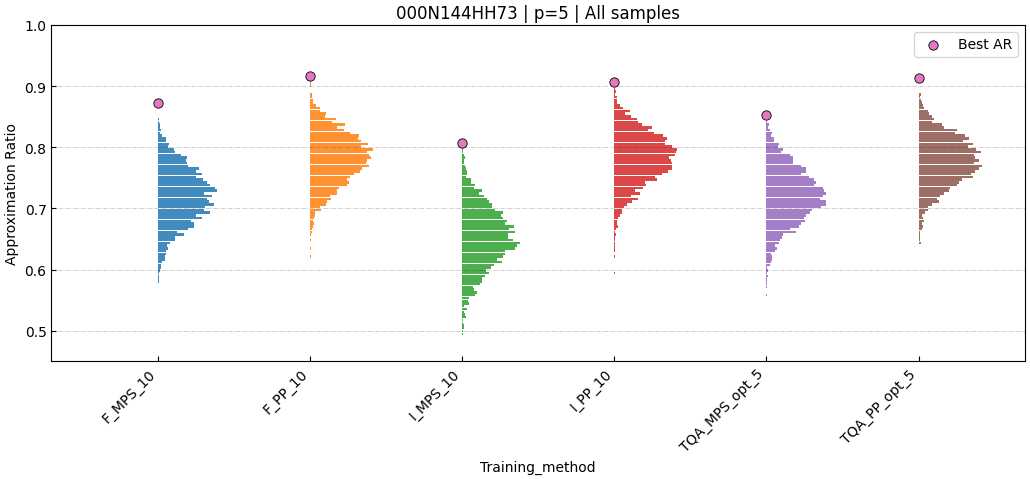

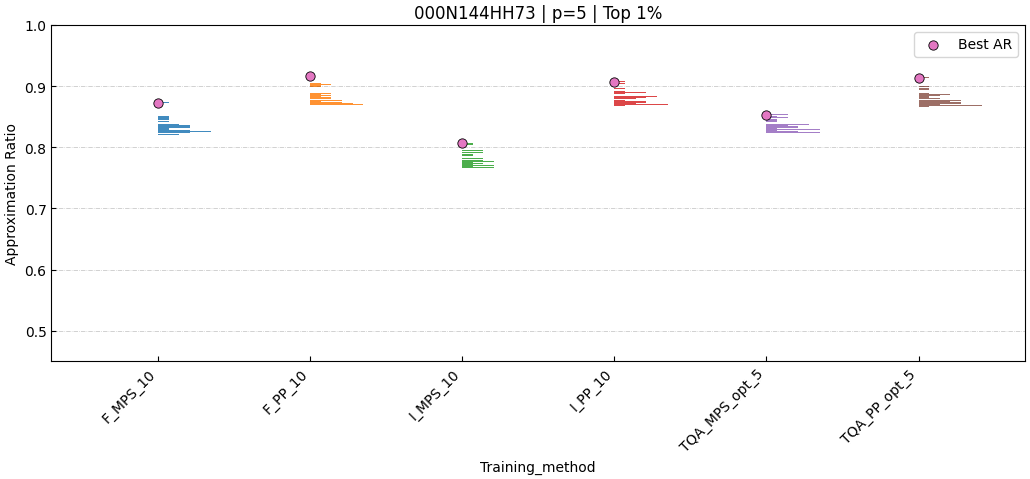

In [8]:
# Plot Distributions for each instance
plot_ar_hist_by_training_method_with_points(df_samples, instance_name="000N144HH73", job_p=5, bins=100, symmetric=False, normalize="global")

In [9]:
# # IMPORTANT FOR HARDWARE PLOTS:
# # "p" should be the HARDWARE job QAOA depth, so job_p controls which plot the point goes into
# df_hardware["p"] = df_hardware["job_p"]

#### Data Analysis for IBM Quantum QAOA Parameter Training Data ####

In [10]:
instance_paths_training = []

for p in p_list:
    for instance in instance_list:
        instance_paths_training.extend(QAOATraining.locate_training_instance(training_data_path, graph_type, instance, 
        num_nodes, p, ER_probability=None, swap_layers=None, degree=None))

In [11]:
all_instances_data_training = []

for instance_path in instance_paths_training:
    obj = QAOATraining.load_training_instance(instance_path)
    all_instances_data_training.append(obj)

# Expand each object into data columns
all_data_dicts_training = []

for obj in all_instances_data_training:
    data_dict_training = {
        "file_name": obj.file_name,
        "pre_processing_time": obj.pre_processing_time,
        "pre_processor_name": obj.pre_processor_name,
        "train_duration_per_iter": obj.train_duration_per_iter,
        "expected_energy_per_iter": obj.expected_energy_per_iter,
        "trainer_name_per_iter": obj.trainer_name_per_iter,
        "train_duration_per_layer": obj.train_duration_per_layer,
        "expected_energy_per_layer": obj.expected_energy_per_layer,
        "trainer_name_per_layer": obj.trainer_name_per_layer,
        "num_depth_iter": obj.num_depth_iter,
    }
    all_data_dicts_training.append(data_dict_training)

In [12]:
# Creata a DataFrame to document the raw extracted training data  
df_training = pd.DataFrame(all_data_dicts_training)

In [13]:
# Clean the DataFrame and report NaN to missing values
df_training = df_training.map(
    lambda x: np.nan if (x is None or x == [] or x == {} or is_empty_nested_list(x)) else x
)

In [14]:
# This cell basically converts the DataFrame from a nested structure to a flat structure for better analysis
flat_rows = []

for _, row in df_training.iterrows():
    file = row["file_name"]

    outer_dur = row["train_duration_per_iter"]
    outer_eng = row["expected_energy_per_iter"]
    outer_trn = row["trainer_name_per_iter"]

    inner_dur   = row["train_duration_per_layer"]
    inner_eng   = row["expected_energy_per_layer"]
    inner_trn   = row["trainer_name_per_layer"]
    inner_depth = row["num_depth_iter"]

    if not isinstance(outer_dur, list):
        continue

    for i in range(len(outer_dur)):
        trn = outer_trn[i] if isinstance(outer_trn, list) and i < len(outer_trn) and isinstance(outer_trn[i], dict) else {}
        min_args = trn.get("minimize_args") if isinstance(trn.get("minimize_args"), dict) else {}
        opts = min_args.get("options") if isinstance(min_args.get("options"), dict) else {}

        flat_rows.append({
            "file_name": file,
            "level": "outer",
            "iteration": i,
            "duration": outer_dur[i] if i < len(outer_dur) else np.nan,
            "energy": outer_eng[i] if isinstance(outer_eng, list) and i < len(outer_eng) else np.nan,
            "trainer": trn.get("trainer_name"),
            "method": min_args.get("method"),
            "maxiter": opts.get("maxiter"),
            "depth_step": np.nan,
        })

        # nested lists
        dur_i   = inner_dur[i]   if isinstance(inner_dur, list)   and i < len(inner_dur)   and isinstance(inner_dur[i], list)   else []
        eng_i   = inner_eng[i]   if isinstance(inner_eng, list)   and i < len(inner_eng)   and isinstance(inner_eng[i], list)   else []
        trn_i   = inner_trn[i]   if isinstance(inner_trn, list)   and i < len(inner_trn)   and isinstance(inner_trn[i], list)   else []
        depth_i = inner_depth[i] if isinstance(inner_depth, list) and i < len(inner_depth) and isinstance(inner_depth[i], list) else []

        for dur, eng, trn2, depth in zip(dur_i, eng_i, trn_i, depth_i):
            trn2 = trn2 if isinstance(trn2, dict) else {}
            min_args2 = trn2.get("minimize_args") if isinstance(trn2.get("minimize_args"), dict) else {}
            opts2 = min_args2.get("options") if isinstance(min_args2.get("options"), dict) else {}

            flat_rows.append({
                "file_name": file,
                "level": "inner",
                "iteration": i,
                "depth_step": depth,
                "duration": dur,
                "energy": eng,
                "trainer": trn2.get("trainer_name"),
                "method": min_args2.get("method"),
                "maxiter": opts2.get("maxiter"),
            })

df_flat = pd.DataFrame(flat_rows)

In [15]:
# Compute approximation ratio for each object and append to the DataFrame. Use the same cache created for hardware data
approximation_ratio_training = []

for _, row in df_flat.iterrows():
    file_name = row["file_name"]
    energy = row["energy"] 
    instance_number = file_name[:3]
    if instance_number not in minmax_cache:
        minmax_instance_path = get_minmax(minmax_path, graph_type, instance_number, num_nodes) # Extract specific minmax_instance path
        minmax_cache[instance_number] = extract_minmax_args(minmax_instance_path) # Cache args for the speciic instance
    min_cut, max_cut, sum_weights = minmax_cache[instance_number] # Extract minmax args for the specific instance
    approximation_ratio_training.append(maxcut_approximation_ratio(min_cut, max_cut, sum_weights, energy)) # Evlaute approximation ratio for that row
df_flat["approximation_ratio"] = approximation_ratio_training  

In [16]:
display(df_flat.head())

,file_name,level,iteration,duration,energy,trainer,method,maxiter,depth_step,approximation_ratio
0,000N144HH73_MC_TQA_PP_optMW6_5.json,outer,0,51.947217,41.776728,TQATrainer,None,NaN,NaN,0.834771
1,000N144HH73_MC_TQA_PP_optMW6_5.json,outer,1,317.832036,47.329537,ScipyTrainer,COBYLA,100.0,NaN,0.879267
2,000N144HH73_MC_TQA_MPS_optBD24_5.json,outer,0,168.914388,23.959557,TQATrainer,None,NaN,NaN,0.691996
3,000N144HH73_MC_TQA_MPS_optBD24_5.json,outer,1,429.027518,27.558751,ScipyTrainer,COBYLA,50.0,NaN,0.720837
4,000N144HH73_MC_LR_MPSAer_opt_DB32_5.json,outer,0,1370.713757,44.877252,TQATrainer,None,NaN,NaN,0.859616


#### Integrating with Stochastic Benchmark Framework ####

In [17]:
# Some pandas DataFame manipulation to generate cumulative times of training duration at each depth
df_SB = df_flat.copy()
df_SB["depth_step"] = pd.to_numeric(df_SB["depth_step"], errors="coerce")
df_SB["iteration"]  = pd.to_numeric(df_SB["iteration"],  errors="coerce")

df_hw = df_hardware.copy()
df_hw["job_p"] = pd.to_numeric(df_hw["job_p"], errors="coerce").astype("float64")

# Inner cumulative duration per file_name by depth_step 
inner = (
    df_SB.loc[df_SB["level"].eq("inner") & df_SB["depth_step"].notna(),
              ["file_name", "depth_step", "duration"]]
        .groupby(["file_name", "depth_step"], as_index=False)["duration"].sum()
        .sort_values(["file_name", "depth_step"])
)

inner["inner_cum"] = inner.groupby("file_name")["duration"].cumsum()
inner["depth_step"] = inner["depth_step"].astype("float64")

# Groupwise asof merge
asof_per_file = make_asof_per_file(inner)

df_hw_with_inner = (
    df_hw.groupby("file_name", group_keys=False)
         .apply(asof_per_file)
)

# If you want to keep rows where job_p was NaN, add them back with 0
df_hw_nan = df_hw[df_hw["job_p"].isna()].copy()
df_hw_nan["inner_duration_sum"] = 0.0
df_hw_with_inner = pd.concat([df_hw_with_inner, df_hw_nan], ignore_index=True, sort=False)

# Outer init (iteration 0/1) per file_name
outer_init = (
    df_SB.loc[df_SB["level"].eq("outer") & df_SB["iteration"].isin([0, 1]),
              ["file_name", "duration"]]
        .groupby("file_name", as_index=False)["duration"].sum()
        .rename(columns={"duration": "outer_init_duration_sum"})
)

# Total training duration per hardware row
df_hardware_new = df_hw_with_inner.merge(outer_init, on="file_name", how="left", validate="m:1")
df_hardware_new["outer_init_duration_sum"] = df_hardware_new["outer_init_duration_sum"].fillna(0.0)

df_hardware_new["total_train_cost"] = (
    df_hardware_new["outer_init_duration_sum"] + df_hardware_new["inner_duration_sum"]
)

In [18]:
display(df_hardware_new.head())

,instance_name,QPU_time (s),num_shots,problem_class,training_method,expected_energy,file_name,job_p,training_p,counts,approximation_ratio,inner_duration_sum,outer_init_duration_sum,total_train_cost
0,000N144HH73,8,4096,maxcut,F_MPS_10,27.752374,000N144HH73_MC_F_MPS_optBD24_10.json,5.0,10,{'11101001001110010001010100011000110110011011...,0.722389,1328.645484,10.210955,1338.856439
1,000N144HH73,9,4096,maxcut,F_MPS_10,22.640265,000N144HH73_MC_F_MPS_optBD24_10.json,10.0,10,{'11100111111110011000010011101010001110101011...,0.681424,4766.826953,10.210955,4777.037908
2,000N144HH73,8,4096,maxcut,F_PP_10,50.809508,000N144HH73_MC_F_PP_optMW6_10.json,5.0,10,{'00101011010101111010101100101000111111100100...,0.907153,928.121308,9.480593,937.601901
3,000N144HH73,9,4096,maxcut,F_PP_10,54.865596,000N144HH73_MC_F_PP_optMW6_10.json,10.0,10,{'10100010100010001111100011110110001100110101...,0.939656,6035.124184,9.480593,6044.604777
4,000N144HH73,8,4096,maxcut,I_MPS_10,24.198928,000N144HH73_MC_I_MPS_optBD24_10.json,5.0,10,{'00010100001010000110111100000000010011001001...,0.693914,1500.992997,9.619366,1510.612363


In [19]:
# Generate the ultimate DataFrame to sum QPU_time and training_time to get the net duration of the experiment for a specific instance row
df_SB_final = df_hardware_new.copy()

df_SB_final["total duration"] = df_SB_final["QPU_time (s)"] + df_SB_final["total_train_cost"]
columns_to_drop = ["QPU_time (s)", "total_train_cost"]
df_SB_final = df_SB_final.drop(columns=columns_to_drop)

In [20]:
display(df_SB_final.head())

,instance_name,num_shots,problem_class,training_method,expected_energy,file_name,job_p,training_p,counts,approximation_ratio,inner_duration_sum,outer_init_duration_sum,total duration
0,000N144HH73,4096,maxcut,F_MPS_10,27.752374,000N144HH73_MC_F_MPS_optBD24_10.json,5.0,10,{'11101001001110010001010100011000110110011011...,0.722389,1328.645484,10.210955,1346.856439
1,000N144HH73,4096,maxcut,F_MPS_10,22.640265,000N144HH73_MC_F_MPS_optBD24_10.json,10.0,10,{'11100111111110011000010011101010001110101011...,0.681424,4766.826953,10.210955,4786.037908
2,000N144HH73,4096,maxcut,F_PP_10,50.809508,000N144HH73_MC_F_PP_optMW6_10.json,5.0,10,{'00101011010101111010101100101000111111100100...,0.907153,928.121308,9.480593,945.601901
3,000N144HH73,4096,maxcut,F_PP_10,54.865596,000N144HH73_MC_F_PP_optMW6_10.json,10.0,10,{'10100010100010001111100011110110001100110101...,0.939656,6035.124184,9.480593,6053.604777
4,000N144HH73,4096,maxcut,I_MPS_10,24.198928,000N144HH73_MC_I_MPS_optBD24_10.json,5.0,10,{'00010100001010000110111100000000010011001001...,0.693914,1500.992997,9.619366,1518.612363


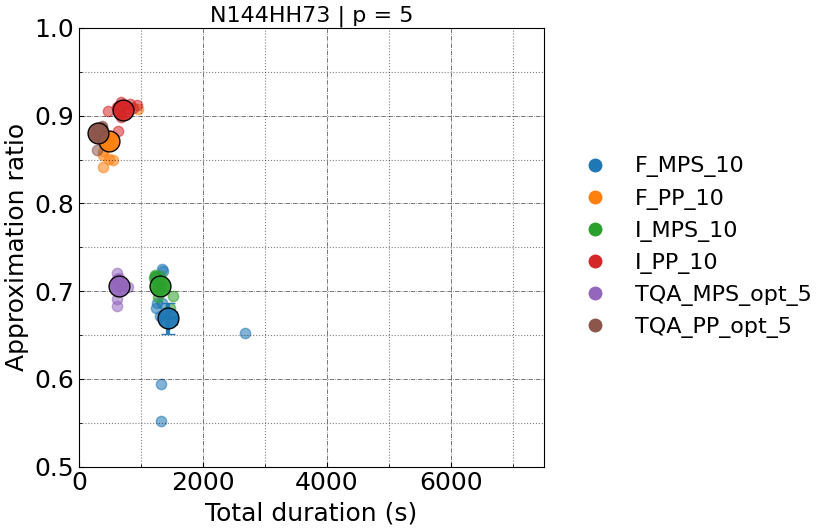

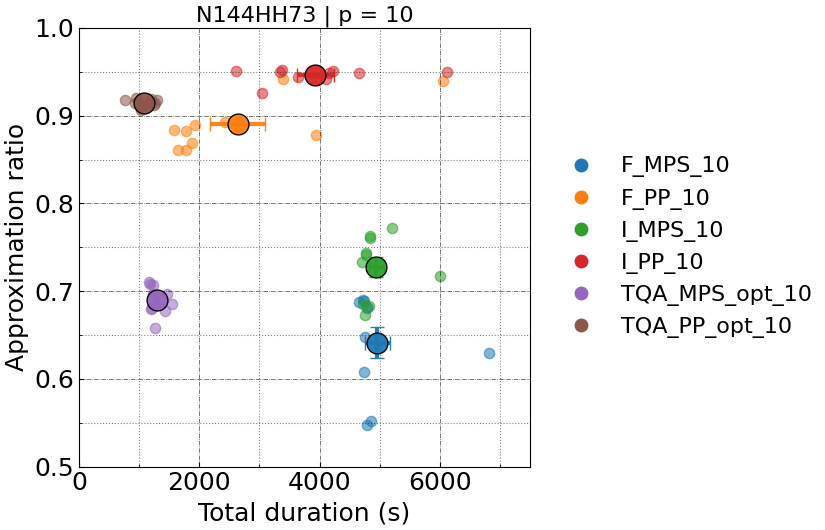

In [21]:
# Performance Plots (Performance Ratio vs Resource)

plt.style.use(ws_style)

FS_TICK = 18
FS_LABEL = 18
FS_TITLE = 16
FS_LEGEND = 16
FS_LEGEND_TITLE = 16
CENTROID_MS = 15

df_plot = df_SB_final.copy()
df_plot["total_duration_s"] = pd.to_numeric(df_plot["total duration"], errors="coerce")
df_plot["approximation_ratio"] = pd.to_numeric(df_plot["approximation_ratio"], errors="coerce")
df_plot["job_p"] = pd.to_numeric(df_plot["job_p"], errors="coerce")

if "instance_name" not in df_plot.columns and "file_name" in df_plot.columns:
    df_plot = df_plot.merge(
        df_hardware[["file_name", "instance_name"]].drop_duplicates(),
        on="file_name",
        how="left",
    )

df_plot = df_plot.dropna(subset=["total_duration_s", "approximation_ratio", "job_p", "file_name"])
df_plot = df_plot[df_plot["total_duration_s"] > 0]

# Build label shown in legend
df_plot["group_label"] = df_plot.get("trainer_label", df_plot.get("training_method", "method")).astype(str)
if "evaluator_label" in df_plot.columns and df_plot["evaluator_label"].nunique(dropna=True) > 1:
    df_plot["group_label"] = df_plot["group_label"] + " | " + df_plot["evaluator_label"].astype(str)

# Color key: strip ONLY trailing _<digits> so TQA_MPS_opt_5 and _10 share a color
df_plot["color_label"] = df_plot["group_label"].str.replace(r"_\d+$", "", regex=True)

df_points = (
    df_plot.groupby(["job_p", "group_label", "color_label", "file_name"], as_index=False)
    .agg(
        total_duration_s=("total_duration_s", "mean"),
        approximation_ratio=("approximation_ratio", "mean"),
        instance_name=("instance_name", "first"),
    )
)

# Global color mapping based on color_label (not group_label)
color_labels_all = sorted(df_points["color_label"].unique())
cmap = plt.get_cmap("tab10")
color_map = {lab: cmap(i % 10) for i, lab in enumerate(color_labels_all)}

p_vals = sorted(df_points["job_p"].unique())

for p in p_vals:
    d = df_points[df_points["job_p"] == p]
    if d.empty:
        continue

    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    # Legend: only labels present at this p, but color by color_label
    present = (
        d[["group_label", "color_label"]]
        .drop_duplicates()
        .sort_values("group_label")
    )
    legend_handles_p = [
        Line2D([0], [0], marker="o", color=color_map[row["color_label"]],
               lw=0, markersize=9, label=row["group_label"])
        for _, row in present.iterrows()
    ]

    # Plot points grouped by displayed label, but colored by color_label
    for (lab, clab), g in d.groupby(["group_label", "color_label"]):
        x = g["total_duration_s"]
        y = g["approximation_ratio"]
        color = color_map[clab]

        ax.scatter(x, y, s=55, alpha=0.55, color=color)

        x_mean = float(x.mean())
        y_mean = float(y.mean())
        x_err = sem(x)
        y_err = sem(y)
        if x_err > 0 and x_mean - x_err <= 0:
            x_err = 0.9 * x_mean

        ax.errorbar(
            x_mean, y_mean,
            xerr=x_err, yerr=y_err,
            fmt="o", ms=CENTROID_MS,
            mfc=color, mec="black", mew=1.0,
            ecolor=color, elinewidth=3,
            capsize=5, capthick=3,
            alpha=0.95, zorder=6
        )

    ax.set_title(title_from_instance_names(d, p), fontsize=FS_TITLE)
    ax.set_xlabel("Total duration (s)", fontsize=FS_LABEL)
    ax.set_ylabel("Approximation ratio", fontsize=FS_LABEL)

    ax.tick_params(axis="both", which="major", labelsize=FS_TICK)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(True, which="major", axis="both", alpha=0.75)
    ax.grid(True, which="minor", axis="both", alpha=0.5, linestyle=":", linewidth=0.8)

    ax.set_xlim(0, 7500)
    ax.set_ylim(0.50, 1.00)

    ax.legend(
        handles=legend_handles_p,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=FS_LEGEND,
        title_fontsize=FS_LEGEND_TITLE,
    )

    plt.tight_layout()
    plt.show()

#### Mean training duration across instances with depth-wise breakdown
This plot summarizes the mean training duration (in seconds) averaged across problem instances for each QAOA depth (`job_p`). Each stacked bar decomposes the total training time into the outer initialization time and per-depth ‘brick’ contributions (depth steps). Error bars represent the standard error of the mean (SEM) across instances. Use this visualization to compare how different training methods scale with depth and to identify which depth steps dominate the training cost.

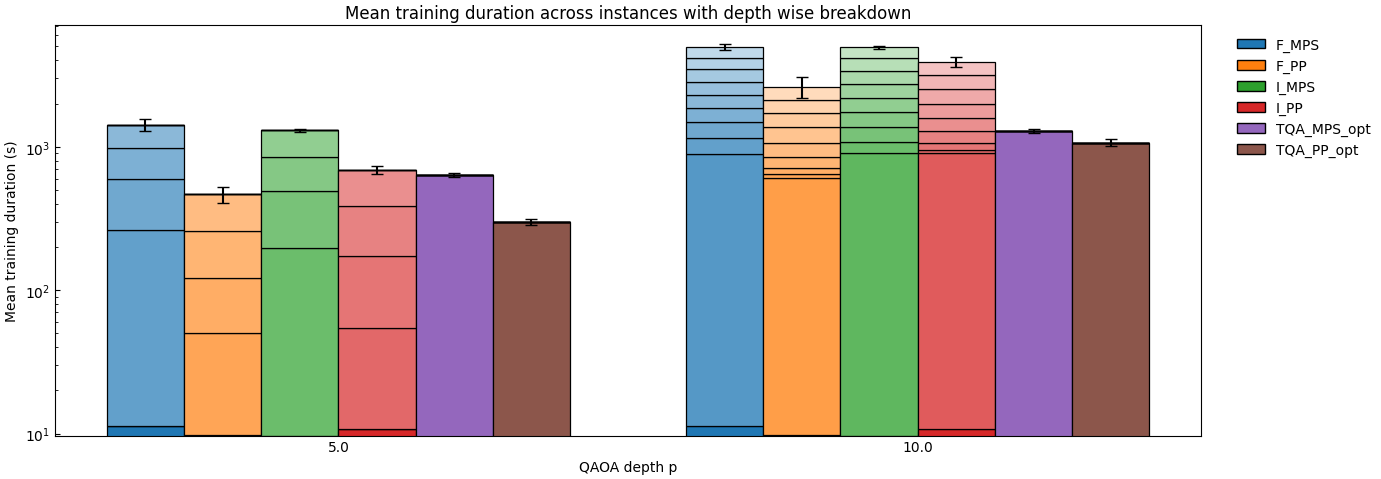

In [22]:
# Plotting for creating histograms of average total duration (training + QPU) for different training_evaluator combinations for each QAOA
# hardware depth across all instances

# Contribution per depth p to the total time
steps = (
    df_flat[df_flat["level"]=="inner"]
    .groupby(["file_name","depth_step"])["duration"]
    .sum()
    .unstack(fill_value=0)
)

steps.columns = [f"step_{int(c)}" for c in steps.columns]
steps = steps.reset_index()

# Init time
outer = (
    df_flat[(df_flat["level"]=="outer") & (df_flat["iteration"].isin([0,1]))]
    .groupby("file_name")["duration"]
    .sum()
    .rename("outer_init")
    .reset_index()
)

# Attach to hardware rows DataFrame
df_rows = df_hardware_new.merge(steps, on="file_name", how="left").merge(outer, on="file_name", how="left").fillna(0)

df_rows["method_base"] = df_rows["training_method"].str.replace(r"_\d+$","",regex=True)

step_cols = [c for c in df_rows.columns if c.startswith("step_")]

# Remove steps > job_p
for c in step_cols:
    k = int(c.split("_")[1])
    df_rows.loc[df_rows["job_p"] < k, c] = 0

df_rows["brick_total"] = df_rows["outer_init"] + df_rows[step_cols].sum(axis=1)

# Final agg for plotting
agg = df_rows.groupby(["job_p","method_base"],as_index=False)[["outer_init","brick_total"]+step_cols].mean()
agg["sem_total"] = df_rows.groupby(["job_p","method_base"])["brick_total"].sem().values

plot_training_bricks(agg, step_cols)